In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as maf
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime

from rubin_scheduler.scheduler.utils import CurrentAreaMap

from rubin_scheduler.utils import DEFAULT_NSIDE, SURVEY_START_MJD, hpid2_ra_dec, Site
from os.path import basename


In [2]:
nside = 128
n_needed=4

In [3]:
def read_sim(dbfile):
    run_name = basename(db_file).replace('.db', '')
    con = sqlite3.connect(db_file)
    df = pd.read_sql('select * from observations;', con)
    con.close()
    # Convert to a numpy array
    visits_array = df.to_records(index=False)
    return visits_array, run_name

In [19]:
sag = CurrentAreaMap(nside=nside)
sky_maps, labels = sag.return_maps()

# 
bands = np.zeros(sky_maps["r"].size, dtype='<U6')
n_bands = sky_maps["r"] * 0
for key in sky_maps.dtype.names:
    ack = sky_maps[key]*0
    indx = np.where(sky_maps[key] > 0)[0]
    ack[indx] = 1
    n_bands += ack
    bands[indx] = np.char.add(bands[indx], key)


indx = np.where(labels != '')[0]
fp_area = indx.size * hp.nside2pixarea(nside, degrees=True)


In [6]:
def seeing_limit_by_dec(nside=128, zenith_fwhm_limit=1.0):
    """Make a seeing limit value a function of declination
    """
    site = Site("LSST")
    hpid = np.arange(hp.nside2npix(nside))
    ra, dec = hpid2_ra_dec(nside, hpid)
    min_z = np.radians(np.abs(dec - site.latitude))
    min_airmass = 1 / np.cos(min_z)
    min_fwhm = zenith_fwhm_limit * (np.power(min_airmass, 0.6))

    # Get rid of NaNs that might be there
    min_fwhm[~np.isfinite(min_fwhm)] = 0

    return min_fwhm


In [7]:
fwhm_template_max = 1.2


In [8]:

class TemplateTime(maf.BaseMetric):
    def __init__(self, col="night", unit="MJD", name="TemplateTime",
                 bands='ugrizy', seeing_limit=1.2, nside=128, n_needed=6,
    seeing_col="seeingFwhmEff", band_col="band", night_col="night"):
        super().__init__(col=col, unit=unit, name=name)
        self.seeing_limit = seeing_limit_by_dec(nside=nside, zenith_fwhm_limit=seeing_limit)
        self.bands = bands
        self.seeing_col = seeing_col
        self.band_col = band_col
        self.night_col = night_col
        self.n_needed = n_needed
        self.badval = np.nan

    def __call__(self, visits, slice_point=None):
        visits.sort(order=self.night_col)
        seeing_limit = self.seeing_limit[slice_point["sid"]]
        night_maxes = []
        
        for bandname in self.bands[slice_point["sid"]]:
            indx = np.where((visits[self.band_col] == bandname) 
                            & (visits[self.seeing_col] <= seeing_limit))[0]
            if np.size(indx) >= self.n_needed:
                night_maxes.append(visits[self.night_col][indx[self.n_needed - 1]])
            else:
                night_maxes.append(self.badval)

        if np.size(night_maxes) > 0:
            result = np.nanmax(night_maxes)
        else:
            result = self.badval
        
        return result

In [9]:
db_files = ["comp_survey_v5.2.0_10yrs.db",
            "../templates_decdep/templates_decdep_v5.2.0_10yrs.db",
            "../templates_decpairs/templates_decpairs_mixed_v5.2.0_10yrs.db", 
           "../templates_fast/templates_fast_mixed_v5.2.0_10yrs.db",
           "../templates_fast/templates_fast_mixed2_v5.2.0_10yrs.db",]
arrays = {}
infos = {}



for db_file in db_files:
    visits_array, run_name = read_sim(db_file)
    
    info = {"run_name": run_name}
    sub_data = visits_array[np.where(visits_array["visitExposureTime"] >=19.)]
    info["observations_subset"] = "expt > 19s"
    sl = maf.Slicer(nside=nside)
    # XXX--setting to 4 for now to try and cut down the missing area a bit
    metric = TemplateTime(nside=nside, n_needed=n_needed, bands=bands)
    hp_array, info = sl(visits_array, metric, info=info)
    arrays[run_name] = hp_array
    infos[run_name] = info


In [ ]:
#hp.mollview(hp_array, max=1200, min=30)

In [ ]:
#hp.mollview(seeing_limit_by_dec(nside=nside, zenith_fwhm_limit=1.2), max=2, min=1.2, title="seeing limit")

In [10]:
arrays

{'comp_survey_v5.2.0_10yrs': array([ nan,  nan,  nan, ..., 187., 187., 187.], shape=(196608,)),
 'templates_decdep_v5.2.0_10yrs': array([ nan,  nan,  nan, ..., 298., 298., 241.], shape=(196608,)),
 'templates_decpairs_mixed_v5.2.0_10yrs': array([ nan,  nan,  nan, ..., 247., 192., 167.], shape=(196608,)),
 'templates_fast_mixed_v5.2.0_10yrs': array([ nan,  nan,  nan, ..., 190., 109., 115.], shape=(196608,)),
 'templates_fast_mixed2_v5.2.0_10yrs': array([ nan,  nan,  nan, ..., 167., 156., 172.], shape=(196608,))}

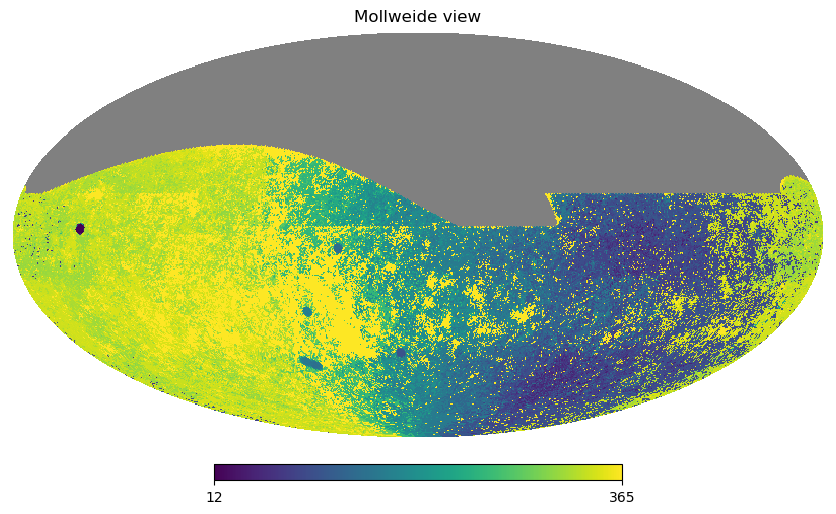

In [11]:
hp.mollview(arrays["comp_survey_v5.2.0_10yrs"], max=365)

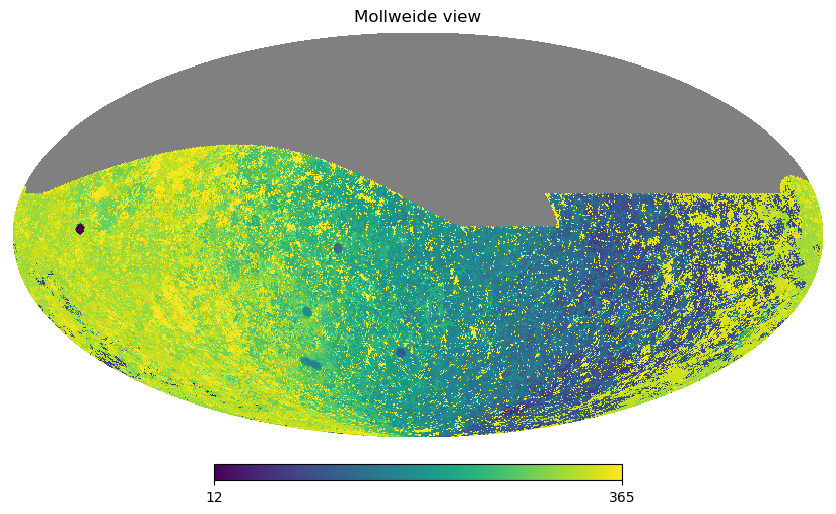

In [12]:
hp.mollview(arrays["templates_decpairs_mixed_v5.2.0_10yrs"], max=365)

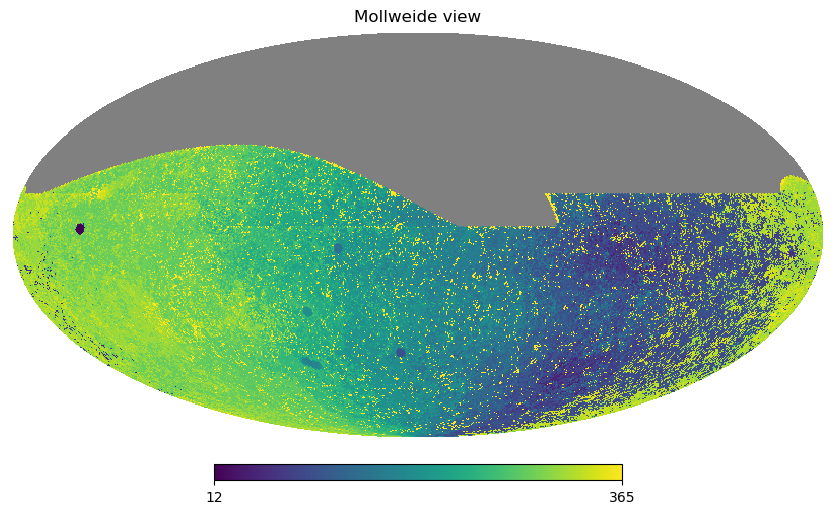

In [13]:
hp.mollview(arrays["templates_decdep_v5.2.0_10yrs"], max=365)

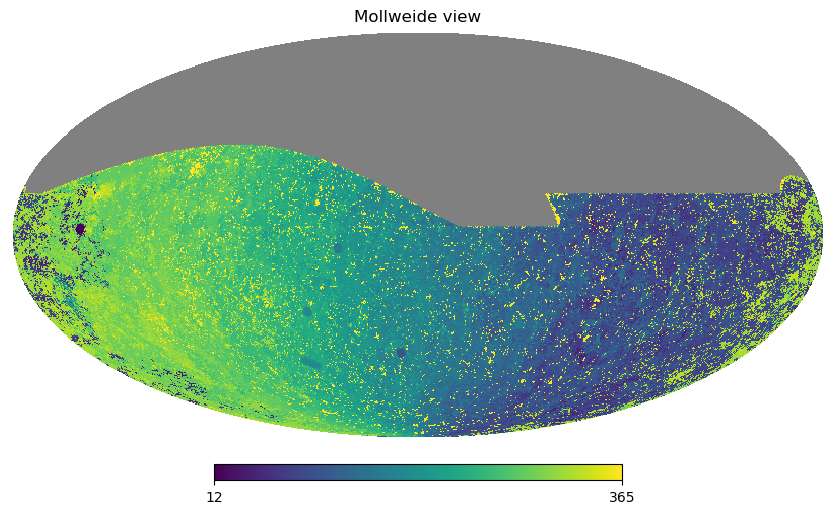

In [14]:
hp.mollview(arrays["templates_fast_mixed_v5.2.0_10yrs"], max=365)

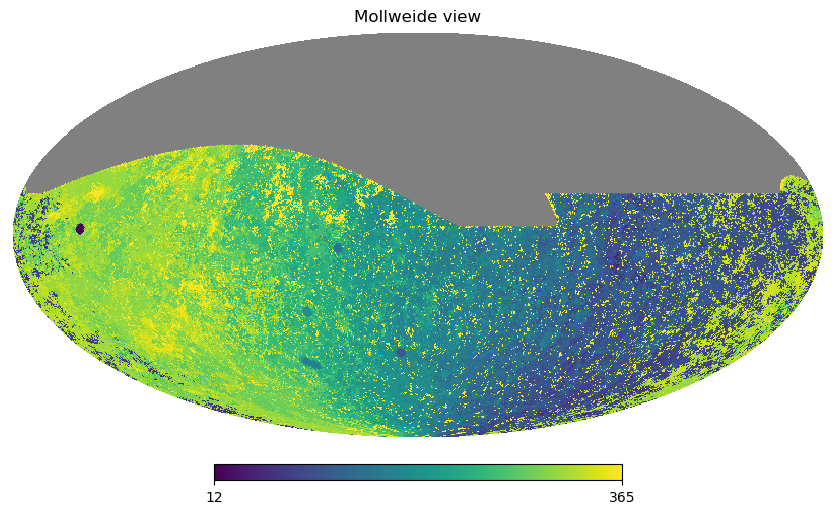

In [15]:
hp.mollview(arrays["templates_fast_mixed2_v5.2.0_10yrs"], max=365)

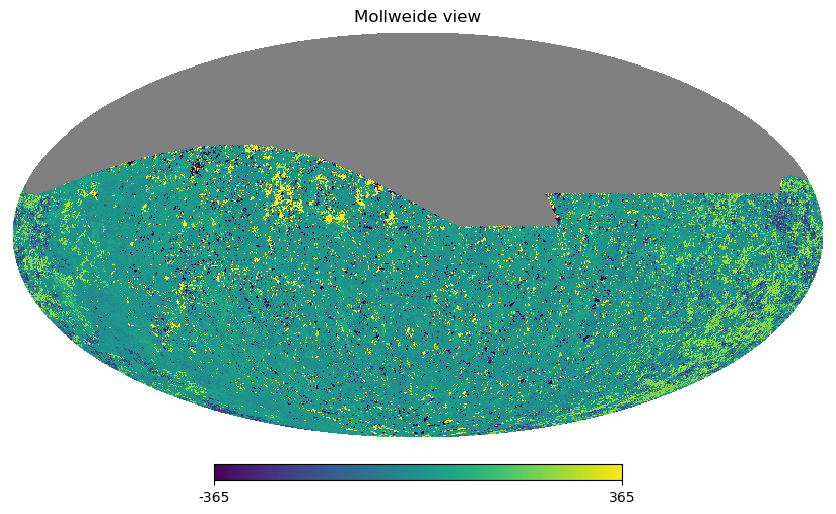

In [16]:
diff = arrays["templates_fast_mixed2_v5.2.0_10yrs"] - arrays["templates_fast_mixed_v5.2.0_10yrs"]
hp.mollview(diff, min=-365, max=365)


Text(0.5, 1.0, '16.0')

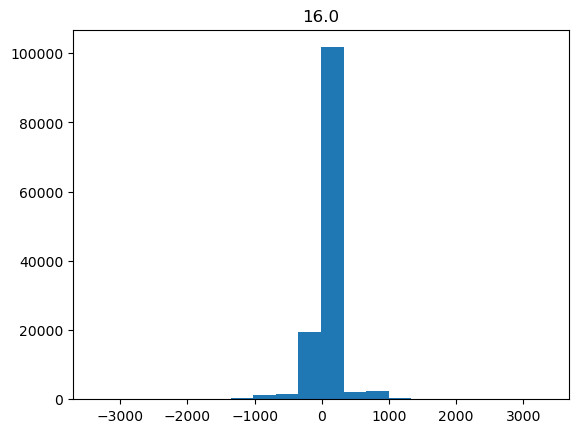

In [17]:

indx = np.isfinite(diff)
_temp = plt.hist(diff[indx], bins=20)
plt.title(np.median(diff[indx]))

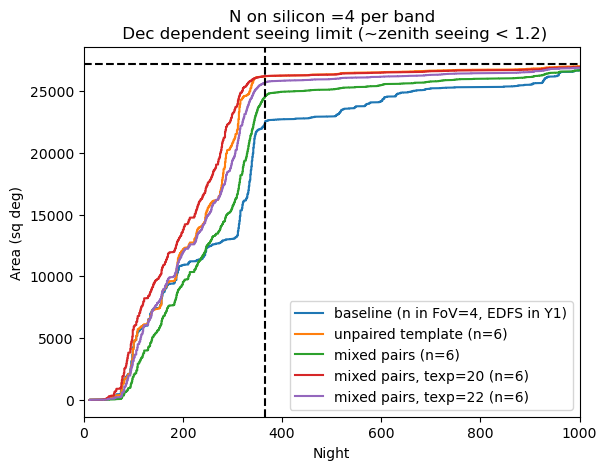

In [28]:
fig, ax = plt.subplots()

ar2label = {'comp_survey_v5.2.0_10yrs': "baseline (n in FoV=4, EDFS in Y1)",
 'templates_decdep_v5.2.0_10yrs': "unpaired template (n=6)",
 'templates_decpairs_mixed_v5.2.0_10yrs': "mixed pairs (n=6)",
 'templates_fast_mixed_v5.2.0_10yrs': "mixed pairs, texp=20 (n=6)",
 'templates_fast_mixed2_v5.2.0_10yrs': "mixed pairs, texp=22 (n=6)"}

for key in arrays:
    ack = arrays[key] +0 
    ack = np.sort(ack)
    ax.plot(ack, np.arange(ack.size)*hp.nside2pixarea(nside, degrees=True), label=ar2label[key])
ax.set_xlim([0,1000])
ax.set_xlabel("Night")
ax.set_ylabel("Area (sq deg)")
ax.set_title("N on silicon = %i per band\n Dec dependent seeing limit (~zenith seeing < 1.2)" % n_needed)
leg = ax.legend()
ax.axvline(x=365, linestyle="--", color="k")
ax.axhline(y=fp_area, linestyle="--", color="k")

In [23]:
arrays


{'comp_survey_v5.2.0_10yrs': array([ nan,  nan,  nan, ..., 187., 187., 187.], shape=(196608,)),
 'templates_decdep_v5.2.0_10yrs': array([ nan,  nan,  nan, ..., 298., 298., 241.], shape=(196608,)),
 'templates_decpairs_mixed_v5.2.0_10yrs': array([ nan,  nan,  nan, ..., 247., 192., 167.], shape=(196608,)),
 'templates_fast_mixed_v5.2.0_10yrs': array([ nan,  nan,  nan, ..., 190., 109., 115.], shape=(196608,)),
 'templates_fast_mixed2_v5.2.0_10yrs': array([ nan,  nan,  nan, ..., 167., 156., 172.], shape=(196608,))}